In [191]:
# This notebook takes the s3m files from the epyc shared filesystem at /epyc/projects/jpl_survey_sim/S3M_v09.05.15/
# The df and array comes from S3Marray.py

In [68]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoom as no
import S3Marray as sm
import importlib
from functools import reduce
importlib.reload(sm)

<module 'S3Marray' from '/astro/users/ds2004/digest3/S3Marray.py'>

In [173]:
s3m = sm.define_s3m()
s3m,array4D, H_center, a_center, e_center, i_center = sm.s3m_array(s3m)

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [131]:
print("min i:", s3m["i"].min())

for eps in [0.1, 0.5, 1.0]:
    print(f"i < {eps} :", (s3m["i"] < eps).sum())


min i: 2e-05
i < 0.1 : 6087
i < 0.5 : 49659
i < 1.0 : 169438


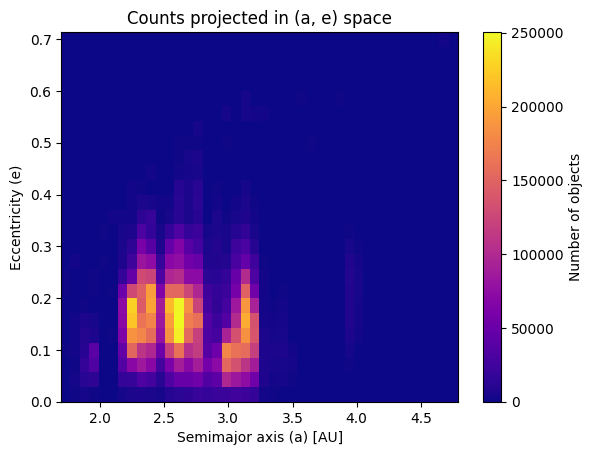

In [169]:

K_ae = array4D.sum(axis=(0, 3))        


plt.imshow(K_ae.T,
           extent=[a_min, a_max, e_min, e_max],
           origin="lower", aspect="auto", cmap="plasma")
plt.xlabel("Semimajor axis (a) [AU]")
plt.ylabel("Eccentricity (e)")
plt.title("Counts projected in (a, e) space")
plt.colorbar(label="Number of objects")
plt.show()


In [181]:
obstime_str="2025-09-23T00:00:00"
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22 # comment out if you're seeing the 5 panel plots
mag = 20.0
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0

# nf = computes abs. mag based on input mag and d, no = uses fixed abs. mag
l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day) # for these, it doesnt matter if you call nf or no
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 

In [179]:
# for the values in vlam/vbet plots 
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22
l_hat, v_hat = no.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = no.get_earth_and_observer(obstime_str) 
mba_score, a, e, i= no.compute_neomod3_weight(1.7, 3.0, l_hat, v_hat, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("mba_score:", mba_score)
print("a:", a)
print("e:", e)
print("i:", i)

mba_score: 0.0
a: -0.901059717188901
e: 3.900959983449875
i: 14.072176739995323


In [182]:
# array4D and center of bins passed from s3m to weight marginalized function --> which passed it to compute_neomod3 --> then to score_from_elements()
def comp_sum1():
    
    N_rate = 31          # make it higher for more resolution
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6

    vlam_vals  = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    vlam_deg_day = 0.12
    vbeta_deg_day = 0.22
    

    
    
    K = np.zeros((len(vlam_vals), len(vbet_vals)), dtype=float)
    
    for i,vlam in enumerate(vlam_vals):
        for j,vbet in enumerate(vbet_vals):
            dra, ddec = no.ecliptic_rates_to_radec_rates(ra0_deg, dec0_deg, vlam, vbet)
            w_int = no.weight_marginalized_over_d_and_ddot(array4D=array4D, H_center=H_center, a_center=a_center, e_center=e_center, i_center=i_center,
                                                        ra_deg=ra0_deg, dec_deg=dec0_deg, dra_deg_per_day=dra, ddec_deg_per_day=ddec,obstime_str=obstime_str
                                                        )
            

            K[j, i] = w_int
            #print(w_int, dra, ddec)
        #break
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent

K, extent= comp_sum1()
N_rate = 31
vlam_vals = np.linspace(-0.6, 0.6, N_rate)
vbet_vals = np.linspace(-0.6, 0.6, N_rate)



In [183]:
# setting value for phi = 0, beta = 0 
phi_deg = 0.0 # on the opposition
beta_deg = 0.0 # on the ecliptic


In [184]:
vE_deg_per_day = 0.986  # earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    # convert angles to radians
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    # from eqn A7 to A8
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    # heliocentric velocity components 
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    # ecliptic rates
    vlam =  (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet


In [185]:
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU 

i_lines = []  # [vlam_arr, vbet_arr, i_deg]

for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


In [186]:
R_list = [2.0, 2.5, 3.0, 3.5]
i_pos = i_center[(i_center >= 0.0) & (i_center <= 40.0)]  # same i-range as neomod3
i_vals_for_R = np.concatenate((-i_pos[::-1], i_pos))
R_lines = []  # [vlam_arr, vbet_arr, R]
for R in R_list:
    vlam_arr = []
    vbet_arr = []
    for i_deg in i_vals_for_R:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    R_lines.append((np.array(vlam_arr), np.array(vbet_arr), R))


(-0.6, 0.6)

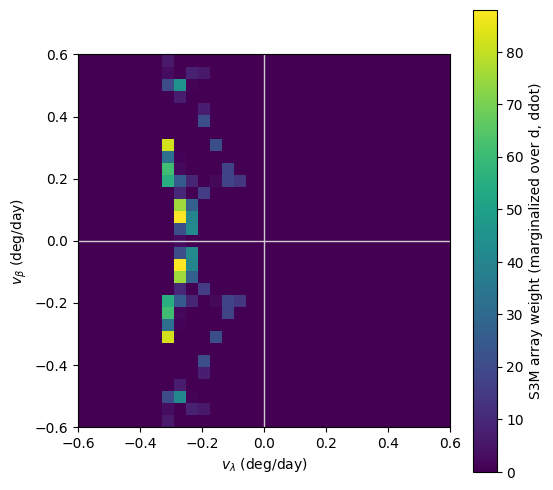

In [196]:
plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M array weight (marginalized over d, ddot)") # its over the array made from s3m and NOT neomod3
plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6,0.6)
plt.ylim(-0.6,0.6)

#### same plot as above, but zoomed in to the same v$\lambda$ and v$\beta$ as fig 14.

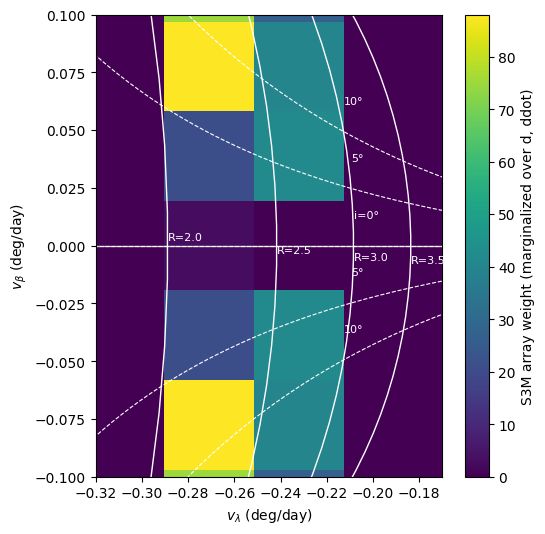

In [195]:
plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M array weight (marginalized over d, ddot)")
plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.32, -0.17)
plt.ylim(-0.1, 0.1)

# solid lines for R
for vlam_arr, vbet_arr, R in R_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=1.0)
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] - 0.012,  # a bit below the line
             f"R={R:.1f}", color="white", fontsize=8)

# dashed lines for i
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, color="white", lw=0.8, ls="--")
    idx = len(vlam_arr) // 2
    plt.text(vlam_arr[idx], vbet_arr[idx] + 0.012,
             f"{abs(i_deg):.0f}°" if i_deg != 0 else "i=0°",
             color="white", fontsize=8)

In [194]:
# checking the value of weight of the pixel at R=2.0, v_beta = 0.0
mask_i = (vlam_vals >= -0.29) & (vlam_vals <= -0.25)
mask_j = (vbet_vals >= -0.025) & (vbet_vals <= 0.025)

K_sub = K[np.ix_(mask_j, mask_i)]
print(K_sub)


[[3.]]
